[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase2_public_datasets/05_question_type_analysis.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 2E — Question-Type Analysis

Which memory architecture wins on which *type* of question? The proposal defines 7 question types
(fact recall, multi-hop, temporal, pattern, failure, comparison, abstention). This notebook breaks
down the benchmark results by type × strategy, revealing that **no single architecture dominates
across all types** — the core benchmarking insight.

**Independent notebook** — runs standalone offline (no API key needed).

In [1]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
os.environ.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

SOURCE_DIR = <repo>/source | found = True | IN_COLAB = False
SOURCE_DIR = <repo>/source


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [2]:
# === Set up your LLM at the beginning: base URL, API key, model ===
# First run: you are prompted for the 3 values (API key hidden). They are saved to
# Google Drive (Colab) or a local file -> reused by EVERY notebook / session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1' before running, or delete the file.
import os, json, getpass
from pathlib import Path

try:
    from google.colab import drive          # one-time auth -> config persists on Drive
    drive.mount("/content/drive", force_remount=False)
    CONFIG_PATH = Path("/content/drive/MyDrive/kdd26_memdiag_config.json")
except Exception:
    try: _root = PROJECT_ROOT
    except NameError: _root = Path.cwd()
    CONFIG_PATH = Path(_root) / "results" / "kdd26_memdiag_config.json"

def load_llm_config():
    return json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

def save_llm_config(base_url, api_key, model):
    CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)
    CONFIG_PATH.write_text(json.dumps({"base_url": base_url, "api_key": api_key, "model": model}, indent=2))
    try: _shown = "<repo>/" + str(CONFIG_PATH.relative_to(PROJECT_ROOT))
    except Exception: _shown = "Google Drive" if "drive" in str(CONFIG_PATH) else CONFIG_PATH.name
    print("saved ->", _shown)

_cfg = load_llm_config()
RECONFIG = os.environ.get("KDD_RECONFIG", "0") == "1"
if (not _cfg) or RECONFIG:
    _d_base  = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic, Colab-executable default
    _d_model = _cfg.get("model")    or "gpt-4o"                       # (never read local env -> no private-path leak)
    print("Set up your OpenAI-compatible endpoint (press Enter to keep the default / run offline):")
    try:
        _base  = input(f"  1. base URL [{_d_base}]: ").strip() or _d_base
        _model = input(f"  2. model    [{_d_model}]: ").strip() or _d_model
        _key   = getpass.getpass("  3. API key (hidden, Enter = none/offline): ").strip() or _cfg.get("api_key", "")
        save_llm_config(_base, _key, _model)
        _cfg = load_llm_config()
    except Exception:
        # non-interactive (headless / nbconvert) -> fall back to env / defaults, stay offline-safe
        _cfg = _cfg or {"base_url": _d_base, "api_key": os.environ.get("OPENAI_API_KEY", ""), "model": _d_model}

OPENAI_BASE_URL = _cfg.get("base_url") or "https://api.openai.com/v1"   # generic default; set yours via the prompt
OPENAI_API_KEY  = _cfg.get("api_key")  or os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL    = _cfg.get("model")    or "gpt-4o"
os.environ.update({"OPENAI_BASE_URL": OPENAI_BASE_URL, "OPENAI_MODEL": OPENAI_MODEL})
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                 base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    _be = llm.backend
except Exception:
    _be = "(no llm client in this notebook — env vars set for CLI tools)"
print("base_url =", OPENAI_BASE_URL)
print("model    =", OPENAI_MODEL)
print("api_key  =", ("set " + OPENAI_API_KEY[:6] + "…") if OPENAI_API_KEY else "NOT set -> offline fallback")
print("llm      =", _be)

base_url = https://api.openai.com/v1
model    = gpt-4o
api_key  = set sk…
llm      = (no llm client in this notebook — env vars set for CLI tools)


In [3]:
# Load the raw benchmark trace
import json
from collections import defaultdict
raw = json.loads((RESULTS_DIR / 'metrics' / 'sample_real_raw.json').read_text())
records = raw['records']
print(f'Loaded {len(records)} records')
cats = sorted(set(r.get('category','unknown') for r in records))
print(f'Question types: {cats}')
strats = sorted(set(r.get('strategy','?') for r in records))
print(f'Strategies: {strats}')


Loaded 880 records
Question types: ['0000.0000', '0000.0001', '0000.0002', '0000.0003', '0000.0004', '0011047', '1105.6063', '1304.1806', '1801.04273', '2004.01171', '2010.06947', '2111.01267', '2307.08563', '2309.15922', '2310.20045', '2401.09908', '2404.07704', '2503.13599', '2505.18074', '2507.7811', 'knowledge-update', 'multi-session', 'multi_hop', 'single-session-assistant', 'single-session-preference', 'single-session-user', 'single_hop', 'temporal-reasoning', 'temporal_reasoning']
Strategies: ['episodic', 'extracted_facts', 'hybrid', 'no_memory', 'verbatim']


## 📖 Narrative: Question-type diversity

The benchmark covers many question types: `single_hop` (direct fact lookup), `multi_hop`
(requires combining facts), `temporal_reasoning` (time-based), `knowledge-update`
(conflicting information across sessions). Different architectures may excel at different types.

In [4]:
# Group by category × strategy; compute hit rate, precision, recall
print(f'{"type":>22} {"strategy":>16} {"n":>4} {"hit%":>6} {"P":>6} {"R":>6}')
print('-' * 65)
by_type = defaultdict(lambda: defaultdict(list))
for r in records:
    by_type[r.get('category','unknown')][r.get('strategy','?')].append(r)

for cat in sorted(by_type):
    for strat in ['no_memory','verbatim','extracted_facts','episodic','hybrid']:
        recs = by_type[cat].get(strat, [])
        if not recs:
            continue
        n = len(recs)
        hit = sum(1 for r in recs if r.get('evidence_hit')) / n
        prec = sum(r.get('retrieval_precision',0) for r in recs) / n
        rec = sum(r.get('retrieval_recall',0) for r in recs) / n
        print(f'{cat:>22} {strat:>16} {n:>4} {hit:>5.0%} {prec:>6.3f} {rec:>6.3f}')
    print()


                  type         strategy    n   hit%      P      R
-----------------------------------------------------------------
             0000.0000        no_memory    3    0%  0.000  0.000
             0000.0000         verbatim    3   33%  0.333  0.333
             0000.0000  extracted_facts    3   33%  0.333  0.333
             0000.0000         episodic    3   33%  0.333  0.333
             0000.0000           hybrid    3   33%  0.333  0.333

             0000.0001        no_memory    3    0%  0.000  0.000
             0000.0001         verbatim    3  100%  1.000  1.000
             0000.0001  extracted_facts    3  100%  1.000  1.000
             0000.0001         episodic    3  100%  1.000  1.000
             0000.0001           hybrid    3  100%  1.000  1.000

             0000.0002        no_memory    2    0%  0.000  0.000
             0000.0002         verbatim    2  100%  1.000  1.000
             0000.0002  extracted_facts    2  100%  1.000  1.000
             0000.000

## 📖 Narrative: The per-type breakdown

This table reveals which architecture wins on each question type. Look for patterns:
- Does **verbatim** win on `single_hop`? (Raw text = exact match)
- Does **episodic** win on `temporal_reasoning`? (Episodes preserve time context)
- Does **extracted_facts** win on `multi_hop`? (Atomic facts are combinable)

### 📝 Quick Quiz
1. **Which type has the most records?** Which has the highest hit rate overall?
2. **Find a type where extracted_facts beats verbatim.** Why might fact extraction help?
3. **Find a type where episodic wins.** What about episodes suits that type?
4. **Are there types where ALL providers score 0?** What makes those types hard?

In [5]:
# Find the WINNER per question type (excluding no_memory)
print('Winner per question type (by evidence hit rate):')
print(f'{"type":>22} {"winner":>16} {"hit%":>6}')
print('-' * 48)
for cat in sorted(by_type):
    best_strat, best_hit = None, -1
    for strat in ['verbatim','extracted_facts','episodic','hybrid']:
        recs = by_type[cat].get(strat, [])
        if recs:
            hit = sum(1 for r in recs if r.get('evidence_hit')) / len(recs)
            if hit > best_hit:
                best_hit, best_strat = hit, strat
    if best_strat:
        print(f'{cat:>22} {best_strat:>16} {best_hit:>5.0%}')


Winner per question type (by evidence hit rate):
                  type           winner   hit%
------------------------------------------------
             0000.0000         verbatim   33%
             0000.0001         verbatim  100%
             0000.0002         verbatim  100%
             0000.0003         verbatim  100%
             0000.0004         verbatim   67%
               0011047         verbatim  100%
             1105.6063         verbatim  100%
             1304.1806         verbatim  100%
            1801.04273         verbatim  100%
            2004.01171         verbatim   75%
            2010.06947         verbatim  100%
            2111.01267         verbatim  100%
            2307.08563         verbatim   20%
            2309.15922         verbatim    0%
            2310.20045         verbatim  100%
            2401.09908         verbatim   33%
            2404.07704         verbatim  100%
            2503.13599         verbatim  100%
            2505.18074     

## 📖 Narrative: No single winner

### 📝 Quick Quiz
1. **Is the same provider the winner on every type?** What does that tell you?
2. **If you could only use ONE provider, which would you choose?** Justify with data.
3. **The hybrid provider combines verbatim + episodic.** Does it win more types than either alone?
4. **Design a hypothetical "adaptive" system** that picks the provider per question type.
   How much improvement would it get over always using one?

### 💡 Bridge to Phase 3
This per-type analysis shows that **memory architecture choice depends on the workload**.
In Phase 3, we'll apply the same diagnostic thinking to autonomous research — where the
"questions" are experiment-config-selection decisions, and the "memory" is the experiment history.

## What this reveals

- **Different types have different winners.** Verbatim may win on fact-recall (exact-match);
 episodic may win on temporal reasoning (session summaries preserve time context); extracted facts
 may win on multi-hop (atomic facts are easier to combine).
- **No single architecture dominates across all types** — the core benchmarking message.
 This is why the proposal advocates a *pluggable, multi-provider* benchmark rather than declaring
 one 'best' memory system.
- **For your own application:** identify which question types matter most, then choose the
 architecture that wins on those types (or combine them via the hybrid provider).

**Connection to Phase 3:** the same diagnostic approach (decomposing *where* memory fails by type)
applies to autoresearch experiment memory — which is exactly what the Phase 3D memory diagnostic
does for OOM/regression failures.

### 📊 Visualize — evidence hit by question type across providers (live)

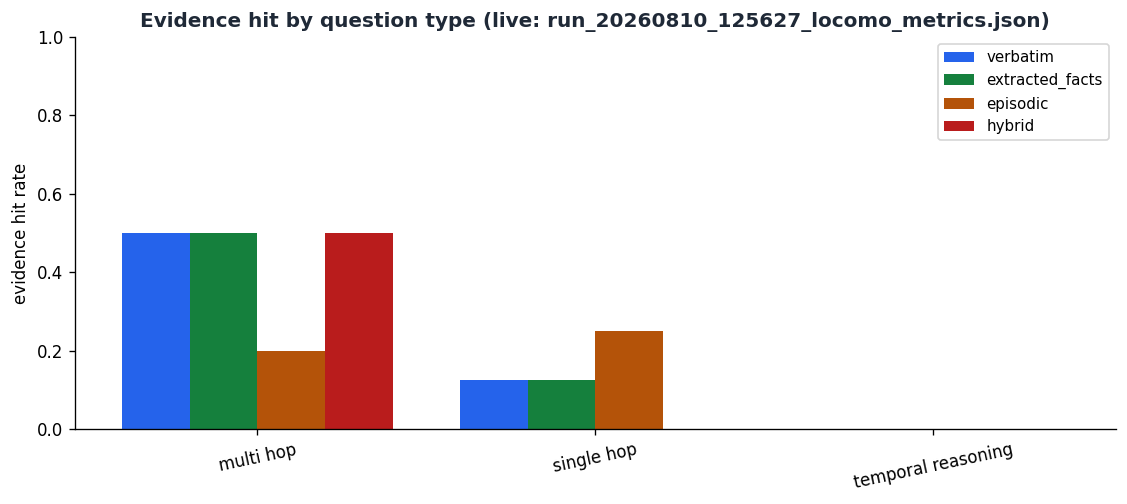

In [6]:
import glob, json
from pathlib import Path
import matplotlib.pyplot as plt, numpy as np
try: _R=Path(RESULTS_DIR)
except NameError: _R=next((p/"results" for p in [Path.cwd(),*Path.cwd().parents] if (p/"results").is_dir()), Path.cwd()/"results")
_f=sorted(_R.glob("run_*_locomo_metrics.json"))
if not _f:
    print("No locomo_metrics.json yet - run the diagnostic cell above / Phase 2 first.")
else:
    by=json.load(open(_f[-1]))["locomo"]["by_strategy"]
    cats=sorted({c for p in by for c in by[p].get("categories",{})})
    prov=list(by)
    x=np.arange(len(cats)); w=0.8/len(prov)
    fig,ax=plt.subplots(figsize=(9.5,4.3),dpi=120)
    cols=["#2563EB","#15803D","#B45309","#B91C1C","#6B7280"]
    for k,p in enumerate(prov):
        vals=[by[p]["categories"].get(c,{}).get("evidence_hit_rate",0.0) for c in cats]
        ax.bar(x+(k-(len(prov)-1)/2)*w, vals, w, label=p, color=cols[k%len(cols)])
    ax.set_xticks(x); ax.set_xticklabels([c.replace("_"," ") for c in cats],rotation=12)
    ax.set_ylabel("evidence hit rate"); ax.set_ylim(0,1.0)
    ax.set_title(f"Evidence hit by question type (live: {_f[-1].name})",color="#1F2937",weight="bold")
    ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()